In [21]:
import re
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ---------- CONFIG ----------
BASE_DIR = Path("/home/ddyob/Documents/tethered_argo/tethered_profiler_simulations/results/config_1")  # adjust if your files live elsewhere
Z_THRESHOLD = -0.20   # "below 20 cm under the water line" (assuming z>0 is up)

# ---------- HELPERS ----------

fname_re = re.compile(
    r"(?P<depth>\d+)m_"
    r"(?P<current>[\d.]+)ms_"
    r"dt(?P<dt>[\deE+-]+)_"
    r"T(?P<T>\d+)s__"
    r"Hs_(?P<Hs>[\d.]+)m_"
    r"Fp_(?P<Fp>[\d.]+)Hz_eta\.pkl$"
)



In [22]:
def final_heave_perc(res, z_thres=-0.2):
    """Return fraction of last 60 s with elevation < z_thres (0–1)."""
    time = res["time_hist"]  # (N,)
    state = res["state_hist"]  # (N, 12)
    try:
        waves = res["waves"]
    except KeyError:
        waves = np.zeros_like(time)

    if np.max(time) <= 100:
        return None

    #print(time)
    # find index where last 60 s starts
    last_60_idx = np.argmin(np.abs(time - (time[-1] - 60.0)))
    print("max time: ", time[-1])
    print("index of closest time", last_60_idx)
    print("time at index: ", time[last_60_idx])
    #print(last_60_idx, print(time[last_60_idx:]))

    heave = state[:, 2]
    last_heaves = heave[last_60_idx:]
    last_waves = waves[last_60_idx:]
    last_elevations = last_heaves - last_waves

    frac_under = np.count_nonzero(last_elevations < z_thres) / last_heaves.shape[0]
    return frac_under  # 0..1


def get_depth_cs_t_hs(file_name):
    """Parse depth, current, Tp, Hs from file name."""
    parts = file_name.split("_")
    depth = float(parts[0][:-1])   # '40m' -> 40
    cs = float(parts[1][:-2])      # '0.10ms' -> 0.10

    if "None" in file_name:
        # No waves case
        Hs = 0.0
        T = 0.0
    else:
        # parts example:
        # ['40m','0.10ms','dt1e-04','T846s','','Hs','1.00m','Fp','0.20Hz','eta.pkl']
        T = 1.0 / float(parts[-2][:-2])   # '0.20Hz' -> 0.20 -> Tp = 1/Fp
        Hs = float(parts[-4][:-1])        # '1.00m'  -> 1.00

    return {
        "depth": depth,
        "current": cs,
        "Tp": T,
        "Hs": Hs,
    }

In [23]:
from __future__ import annotations

from pathlib import Path
from IPython.display import display


def _write_depth_summary_csv(
    *,
    out_path: Path,
    depth: float,
    records: list[dict],
) -> None:
    """
    Writes one CSV per depth with columns:
    depth_m,current_ms,Hs_m,Tp_s,Fp_Hz,frac_submerged
    """
    out_path.parent.mkdir(parents=True, exist_ok=True)

    header = "depth_m,current_ms,Hs_m,Tp_s,Fp_Hz,frac_submerged\n"
    lines = [header]

    for r in records:
        Hs = float(r.get("Hs", np.nan))
        Tp = float(r.get("Tp", np.nan))
        # Convert period -> frequency (Hz). If Tp is 0 or missing, set Fp=0.
        Fp = 0.0 if (not np.isfinite(Tp) or Tp <= 0.0) else 1.0 / Tp

        line = (
            f"{float(depth):.6g},"
            f"{float(r.get('current', np.nan)):.6g},"
            f"{Hs:.6g},"
            f"{Tp:.6g},"
            f"{Fp:.6g},"
            f"{float(r.get('frac', np.nan)):.6g}\n"
        )
        lines.append(line)

    out_path.write_text("".join(lines), encoding="utf-8")


def plot_submergence_heatmap_for_depth(depth: float, base_dir: Path):
    files = sorted(base_dir.glob(f"{int(depth)}m_*.pkl"))
    if not files:
        print(f"No files found for depth={depth} m in {base_dir}")
        return None

    records: list[dict] = []
    for path in files:
        meta = get_depth_cs_t_hs(path.name)
        print(meta)

        with open(path, "rb") as f:
            D = pickle.load(f)

        frac = final_heave_perc(D, z_thres=Z_THRESHOLD)
        if frac is None:
            continue

        meta["frac"] = float(frac)  # 0..1
        records.append(meta)

    if not records:
        print(f"No usable records for depth={depth}")
        return None

    # ---- write per-depth summary ----
    summary_path = base_dir / f"{int(depth)}m_summary.csv"
    _write_depth_summary_csv(out_path=summary_path, depth=depth, records=records)

    # ---- build scatter grid ----
    currents = sorted({r["current"] for r in records})
    wave_keys = sorted({(r["Hs"], r["Tp"]) for r in records}, key=lambda k: (k[0], k[1]))

    n_c, n_w = len(currents), len(wave_keys)
    data = np.full((n_c, n_w), np.nan, dtype=float)

    c_index = {c: i for i, c in enumerate(currents)}
    w_index = {k: j for j, k in enumerate(wave_keys)}

    for r in records:
        data[c_index[r["current"]], w_index[(r["Hs"], r["Tp"])]] = r["frac"]

    valid = np.isfinite(data)
    if not np.any(valid):
        print(f"No finite data for depth={depth}")
        return None

    iy, ix = np.where(valid)
    z = data[iy, ix]

    fig, ax = plt.subplots(figsize=(10, 5))
    sc = ax.scatter(
        ix,
        iy,
        c=z,
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
        s=60,
        edgecolors="k",
        linewidths=0.5,
    )

    xlabels = [
        "No waves" if (Hs == 0.0 and Tp == 0.0) else f"Hs={Hs:.2g} m\nTp={Tp:.1f} s"
        for (Hs, Tp) in wave_keys
    ]
    ax.set_xticks(np.arange(n_w))
    ax.set_xticklabels(xlabels, rotation=45, ha="right")

    ax.set_yticks(np.arange(n_c))
    ax.set_yticklabels([f"{c:.2f}" for c in currents])

    ax.set_xlabel("Wave state (Hs / Tp)")
    ax.set_ylabel("Current speed [m/s]")
    ax.set_title(f"Depth = {depth:.0f} m")

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Fraction of time submerged (> 0.20 m)")

    plt.tight_layout()

    # ---- save figure per depth ----
    fig_path = base_dir / f"{int(depth)}m_heatmap.png"
    fig.savefig(fig_path, dpi=300)

    # Jupyter-friendly display (separate output per depth)
    display(fig)
    plt.close(fig)

    return {"fig_path": fig_path, "summary_path": summary_path}


def plot_all_depths(base_dir: Path):
    depths = sorted({float(p.name.split("_")[0][:-1]) for p in base_dir.glob("*.pkl")})
    if not depths:
        raise FileNotFoundError(f"No .pkl files found in {base_dir}")

    outputs = []
    for d in depths:
        print(f"Plotting depth {d} m")
        out = plot_submergence_heatmap_for_depth(d, base_dir)
        if out is not None:
            outputs.append(out)
    return outputs


# run
outputs = plot_all_depths(BASE_DIR)
outputs


[{'fig_path': PosixPath('/home/ddyob/Documents/tethered_argo/tethered_profiler_simulations/results/config_1/15m_heatmap.png'),
  'summary_path': PosixPath('/home/ddyob/Documents/tethered_argo/tethered_profiler_simulations/results/config_1/15m_summary.csv')},
 {'fig_path': PosixPath('/home/ddyob/Documents/tethered_argo/tethered_profiler_simulations/results/config_1/25m_heatmap.png'),
  'summary_path': PosixPath('/home/ddyob/Documents/tethered_argo/tethered_profiler_simulations/results/config_1/25m_summary.csv')}]

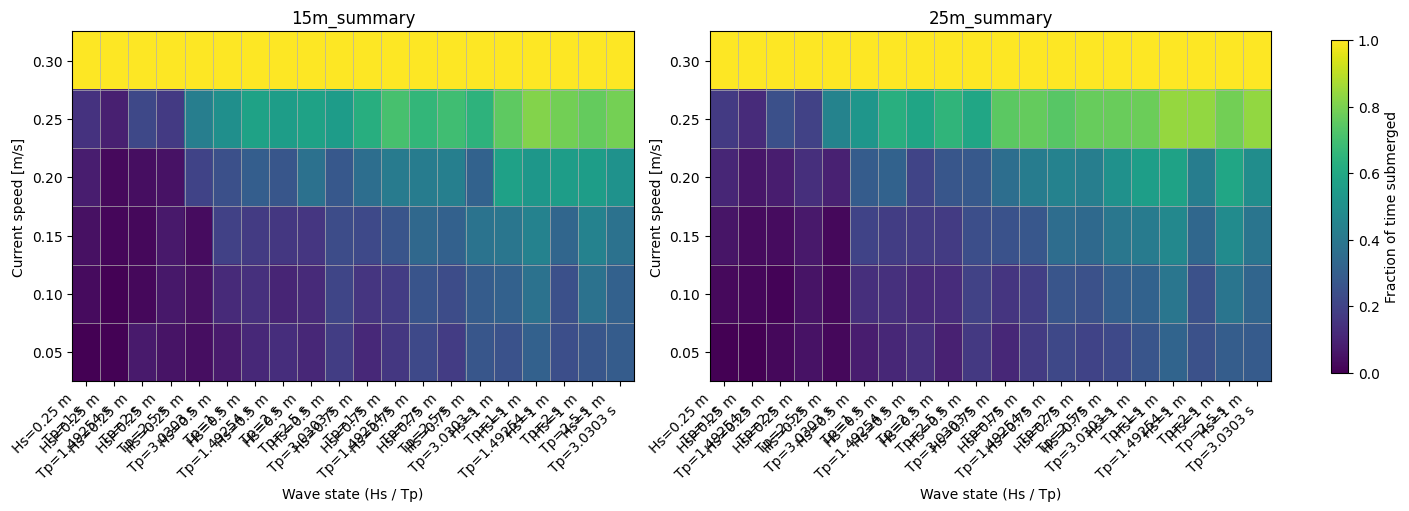

In [24]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _wave_label(hs: float, tp: float) -> str:
    if np.isclose(hs, 0.0) and np.isclose(tp, 0.0):
        return "No waves"
    return f"Hs={hs:g} m\nTp={tp:g} s"


def _prepare_grid(df: pd.DataFrame) -> tuple[np.ndarray, list[float], list[tuple[float, float]], list[str]]:
    """
    Returns:
      Z: (n_current, n_wave) array of frac_submerged
      currents: sorted unique current speeds
      waves: sorted unique (Hs, Tp)
      xlabels: per-wave tick labels
    """
    # normalize column names just in case
    df = df.rename(
        columns={
            "current": "current_ms",
            "Hs": "Hs_m",
            "Tp": "Tp_s",
            "frac": "frac_submerged",
        }
    )

    required = {"current_ms", "Hs_m", "Tp_s", "frac_submerged"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in summary CSV: {missing}")

    currents = sorted(df["current_ms"].unique().tolist())
    waves = sorted(df[["Hs_m", "Tp_s"]].drop_duplicates().itertuples(index=False, name=None), key=lambda k: (k[0], k[1]))
    xlabels = [_wave_label(hs, tp) for hs, tp in waves]

    c_index = {c: i for i, c in enumerate(currents)}
    w_index = {w: j for j, w in enumerate(waves)}

    Z = np.full((len(currents), len(waves)), np.nan, dtype=float)
    for r in df.itertuples(index=False):
        i = c_index[float(getattr(r, "current_ms"))]
        w = (float(getattr(r, "Hs_m")), float(getattr(r, "Tp_s")))
        j = w_index[w]
        Z[i, j] = float(getattr(r, "frac_submerged"))

    return Z, currents, waves, xlabels


def plot_block_heatmap(ax, df: pd.DataFrame, title: str):
    Z, currents, waves, xlabels = _prepare_grid(df)

    # Mask missing cells so they render as "empty"
    Zm = np.ma.masked_invalid(Z)

    im = ax.imshow(
        Zm,
        origin="lower",
        aspect="auto",
        vmin=0.0,
        vmax=1.0,
        interpolation="nearest",
    )

    ax.set_title(title)
    ax.set_xlabel("Wave state (Hs / Tp)")
    ax.set_ylabel("Current speed [m/s]")

    ax.set_xticks(np.arange(len(waves)))
    ax.set_xticklabels(xlabels, rotation=45, ha="right")

    ax.set_yticks(np.arange(len(currents)))
    ax.set_yticklabels([f"{c:.2f}" for c in currents])

    # grid lines to emphasize "blocks"
    ax.set_xticks(np.arange(-0.5, len(waves), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(currents), 1), minor=True)
    ax.grid(which="minor", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im


def plot_depths_side_by_side(csv_left: Path, csv_right: Path, *, savepath: Path | None = None):
    df1 = pd.read_csv(csv_left)
    df2 = pd.read_csv(csv_right)

    # If these CSVs contain multiple depths, filter to the first depth in each file
    if "depth_m" in df1.columns and df1["depth_m"].nunique() > 1:
        d = float(df1["depth_m"].unique()[0])
        df1 = df1[df1["depth_m"] == d]
    if "depth_m" in df2.columns and df2["depth_m"].nunique() > 1:
        d = float(df2["depth_m"].unique()[0])
        df2 = df2[df2["depth_m"] == d]

    title1 = f"{csv_left.stem}"
    title2 = f"{csv_right.stem}"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    im1 = plot_block_heatmap(axes[0], df1, title1)
    im2 = plot_block_heatmap(axes[1], df2, title2)

    # One shared colorbar
    cbar = fig.colorbar(im2, ax=axes, shrink=0.95)
    cbar.set_label("Fraction of time submerged")

    if savepath is not None:
        savepath.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(savepath, dpi=300)

    plt.show()


# Example (your uploaded files)
plot_depths_side_by_side(
    Path("/home/ddyob/Documents/tethered_argo/tethered_profiler_simulations/results/config_1/15m_summary.csv"),
    Path("/home/ddyob/Documents/tethered_argo/tethered_profiler_simulations/results/config_1/25m_summary.csv"),
    savepath=Path("15m_vs_25m_block_heatmaps.png"),
)


Plotting depth 10.0 m
max time:  586.600050007945
index of closest time 4667
time at index:  466.6000500208629
max time:  586.600050007945
index of closest time 4667
time at index:  466.6000500208629
max time:  586.600050007945
index of closest time 4667
time at index:  466.6000500208629
max time:  586.600050007945
index of closest time 4667
time at index:  466.6000500208629
max time:  586.600050007945
index of closest time 4667
time at index:  466.6000500208629
max time:  586.600050007945
index of closest time 4667
time at index:  466.6000500208629
max time:  586.600050007945
index of closest time 4667
time at index:  466.6000500208629
max time:  586.600050007945
index of closest time 4667
time at index:  466.6000500208629
max time:  586.600050007945
index of closest time 4667
time at index:  466.6000500208629
max time:  586.600050007945
index of closest time 4667
time at index:  466.6000500208629
max time:  586.600050007945
index of closest time 4667
time at index:  466.6000500208629

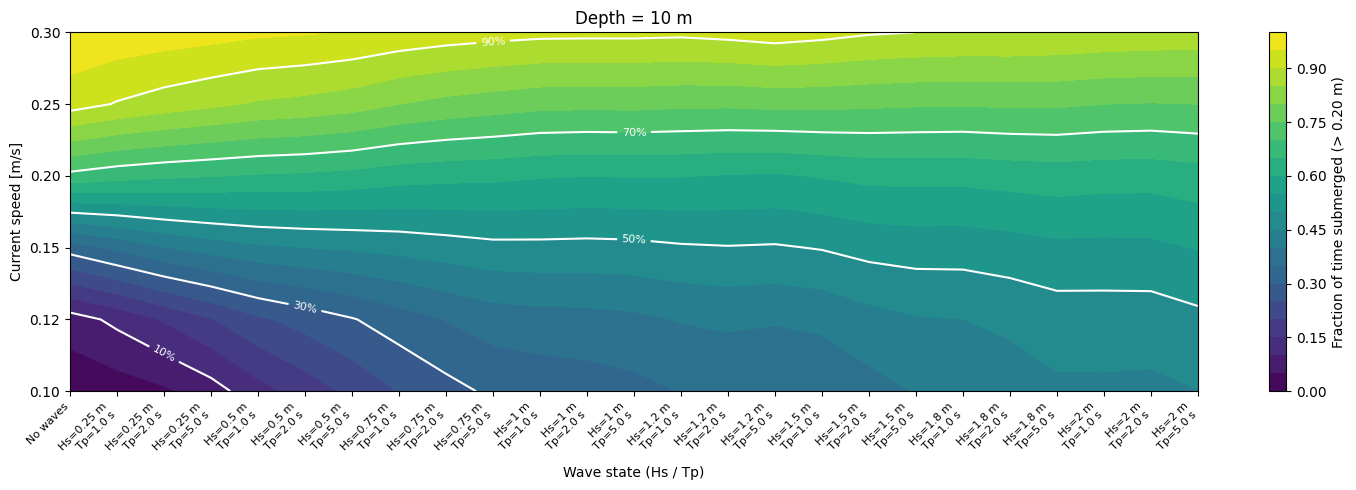

Plotting depth 20.0 m
max time:  673.2001499862066
index of closest time 5533
time at index:  553.2000000163291
max time:  673.2001499862066
index of closest time 5533
time at index:  553.2000000163291
max time:  673.2001499862066
index of closest time 5533
time at index:  553.2000000163291
max time:  673.2001499862066
index of closest time 5533
time at index:  553.2000000163291
max time:  673.2001499862066
index of closest time 5533
time at index:  553.2000000163291
max time:  673.2001499862066
index of closest time 5533
time at index:  553.2000000163291
max time:  673.2001499862066
index of closest time 5533
time at index:  553.2000000163291
max time:  673.2001499862066
index of closest time 5533
time at index:  553.2000000163291
max time:  673.2001499862066
index of closest time 5533
time at index:  553.2000000163291
max time:  673.2001499862066
index of closest time 5533
time at index:  553.2000000163291
max time:  673.2001499862066
index of closest time 5533
time at index:  553.20

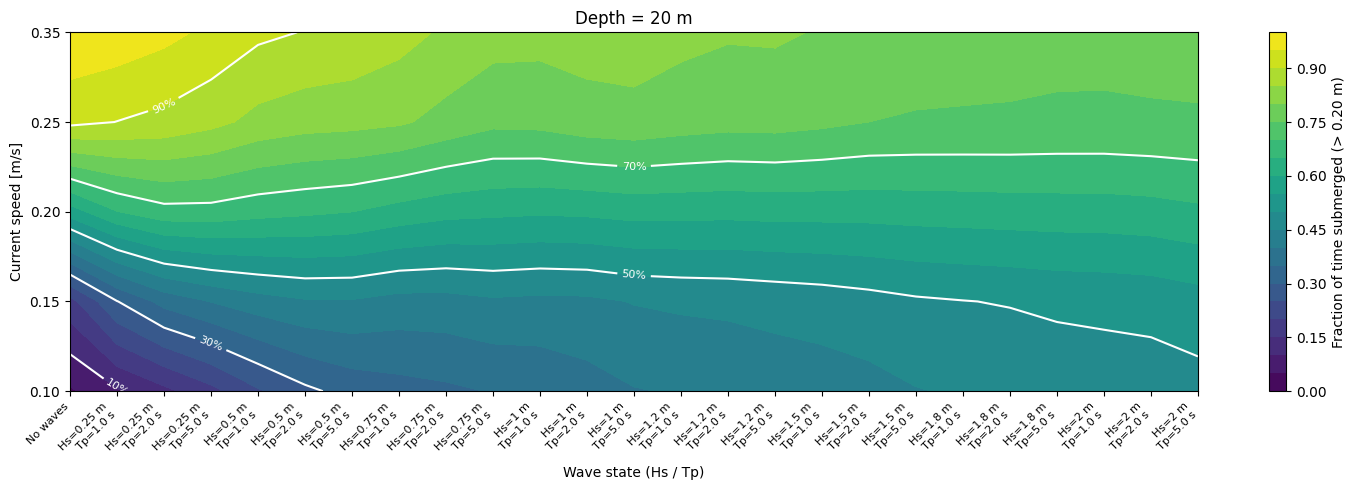

Plotting depth 40.0 m
max time:  846.4000499427299
index of closest time 7265
time at index:  726.4000499728523
max time:  846.4000499427299
index of closest time 7265
time at index:  726.4000499728523
max time:  846.4000499427299
index of closest time 7265
time at index:  726.4000499728523
max time:  846.4000499427299
index of closest time 7265
time at index:  726.4000499728523
max time:  846.4000499427299
index of closest time 7265
time at index:  726.4000499728523
max time:  846.4000499427299
index of closest time 7265
time at index:  726.4000499728523
max time:  846.4000499427299
index of closest time 7265
time at index:  726.4000499728523
max time:  846.4000499427299
index of closest time 7265
time at index:  726.4000499728523
max time:  846.4000499427299
index of closest time 7265
time at index:  726.4000499728523
max time:  846.4000499427299
index of closest time 7265
time at index:  726.4000499728523
max time:  846.4000499427299
index of closest time 7265
time at index:  726.40

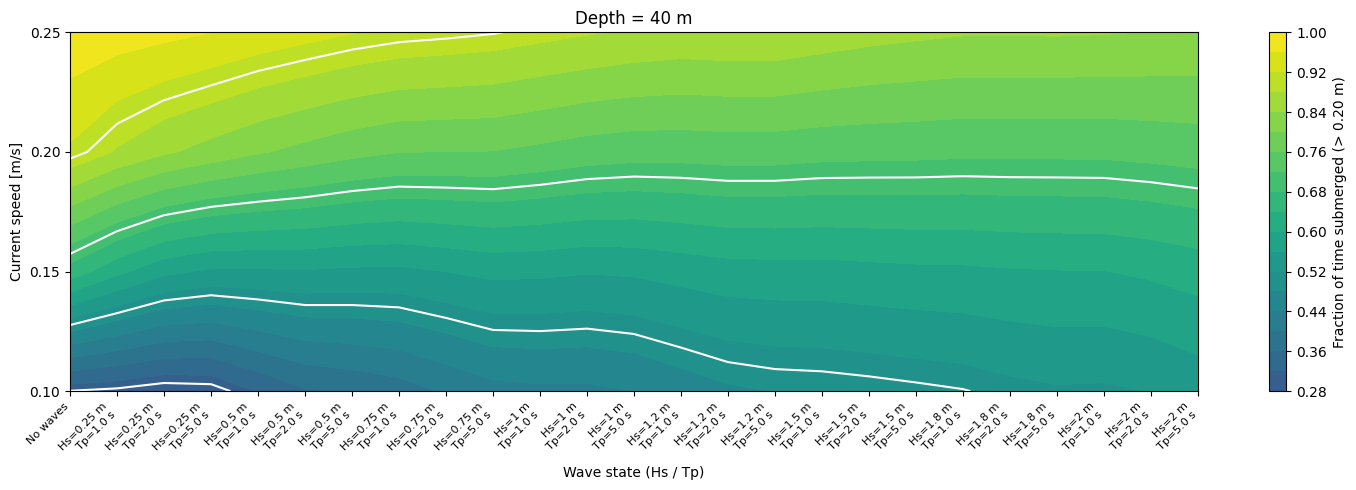

Plotting depth 60.0 m
max time:  450.30000001877755
index of closest time 3304
time at index:  330.3000000034253
max time:  456.50010001957077
index of closest time 3366
time at index:  336.5001000042185
max time:  410.10000001363454
index of closest time 2902
time at index:  290.1001499982823
max time:  460.7001000201081
index of closest time 3408
time at index:  340.7001000047558
max time:  415.3000500142998
index of closest time 2954
time at index:  295.30004999894754
max time:  1019.6000998992531
index of closest time 8997
time at index:  899.6000999293756
max time:  418.3000500146836
index of closest time 2984
time at index:  298.30004999933135
max time:  846.4001999308082
index of closest time 7265
time at index:  726.4001999609306
max time:  846.4001999308082
index of closest time 7265
time at index:  726.4001999609306
max time:  846.4001999308082
index of closest time 7265
time at index:  726.4001999609306
max time:  846.4001999308082
index of closest time 7265
time at index:  

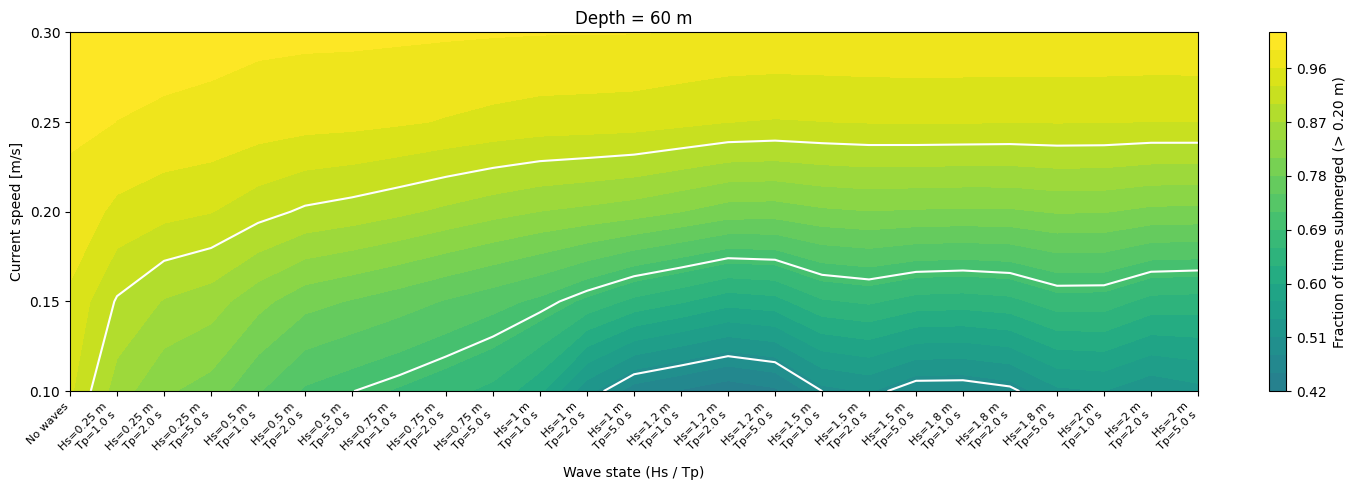

Plotting depth 80.0 m
max time:  428.60010001600136
index of closest time 3087
time at index:  308.6001000006491
max time:  425.0001000155408
index of closest time 3051
time at index:  305.0001000001885
max time:  424.6000500154896
index of closest time 3047
time at index:  304.60005000013734
max time:  434.70000001678176
index of closest time 3148
time at index:  314.7000000014295
max time:  426.2001000156943
index of closest time 3063
time at index:  306.20010000034205
max time:  425.0001000155408
index of closest time 3051
time at index:  305.0001000001885
max time:  428.40000001597576
index of closest time 3085
time at index:  308.4000000006235
max time:  425.50005001560476
index of closest time 3056
time at index:  305.5000500002525
max time:  460.5000000200825
index of closest time 3406
time at index:  340.5000000047302
max time:  430.30005001621885
index of closest time 3104
time at index:  310.3000500008666
max time:  426.4000500157199
index of closest time 3065
time at index: 

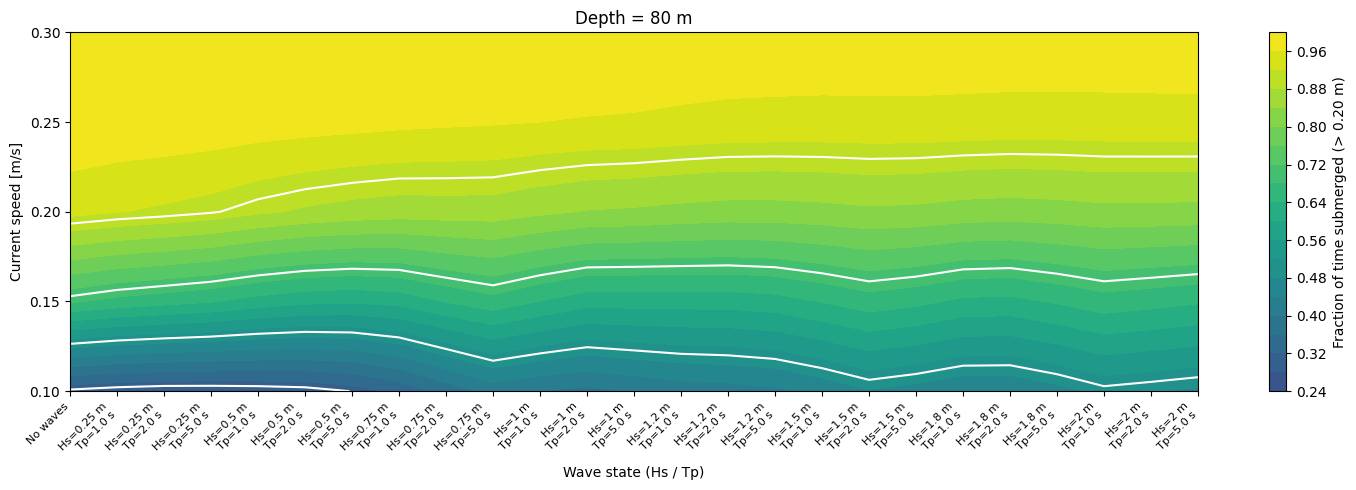

Plotting depth 100.0 m
max time:  471.8001000215282
index of closest time 3519
time at index:  351.8001000061759
max time:  469.6000500212467
index of closest time 3497
time at index:  349.60005000589445
max time:  469.40010002122114
index of closest time 3495
time at index:  349.40010000586886
max time:  474.2001000218352
index of closest time 3543
time at index:  354.20010000648296
max time:  470.2000500213235
index of closest time 3503
time at index:  350.2000500059712
max time:  469.6000500212467
index of closest time 3497
time at index:  349.60005000589445
max time:  479.90010002256446
index of closest time 3600
time at index:  359.9001000072122
max time:  471.3000000214642
index of closest time 3514
time at index:  351.30000000611193
max time:  469.8000000212723
index of closest time 3499
time at index:  349.80000000592
max time:  486.10005002335765
index of closest time 3662
time at index:  366.1000500080054
max time:  472.7001000216433
index of closest time 3528
time at index: 

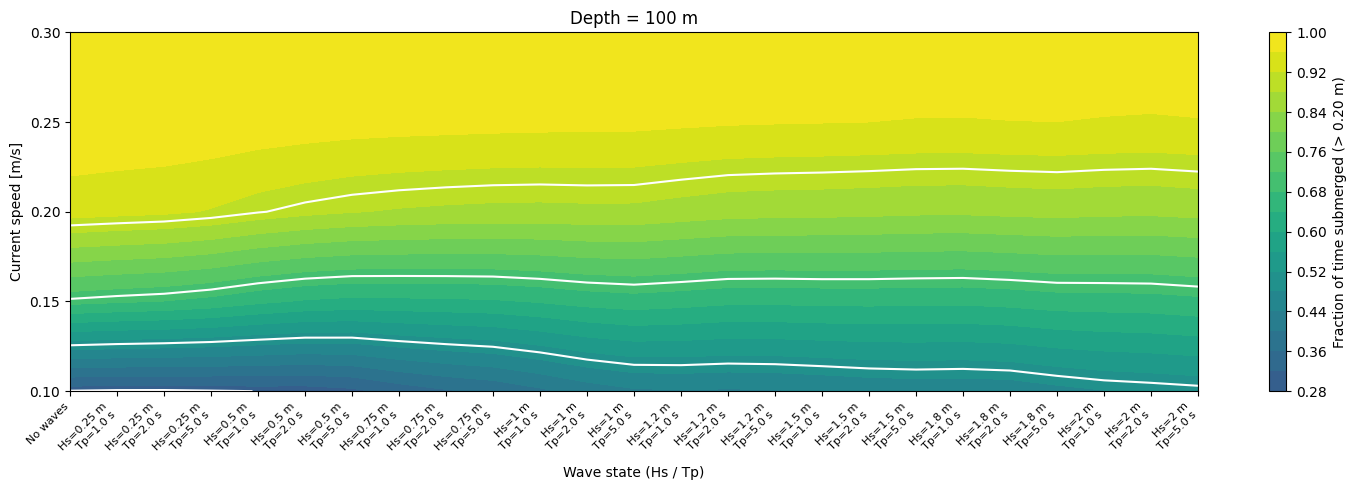

In [6]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter  # smoothing


def plot_submergence_contour_for_depth(depth: float, base_dir: Path):
    files = sorted(base_dir.glob(f"{int(depth)}m_*.pkl"))
    if not files:
        print(f"No files found for depth={depth} m in {base_dir}")
        return

    records = []
    for path in files:
        fname = path.name
        meta = get_depth_cs_t_hs(fname)  # your existing parser

        with open(path, "rb") as f:
            D = pickle.load(f)

        frac = final_heave_perc(D, z_thres=Z_THRESHOLD)  # your existing function
        if frac is None:
            continue

        meta["frac"] = frac  # 0..1
        records.append(meta)

    if not records:
        print(f"No usable records for depth={depth}")
        return

    # unique currents and wave states
    currents = sorted({r["current"] for r in records})
    wave_keys = sorted({(r["Hs"], r["Tp"]) for r in records}, key=lambda k: (k[0], k[1]))

    n_c = len(currents)
    n_w = len(wave_keys)

    # grid: rows = current, cols = (Hs,Tp)
    data = np.full((n_c, n_w), np.nan, dtype=float)

    c_index = {c: i for i, c in enumerate(currents)}
    w_index = {k: j for j, k in enumerate(wave_keys)}

    for r in records:
        i = c_index[r["current"]]
        j = w_index[(r["Hs"], r["Tp"])]
        data[i, j] = r["frac"]  # 0..1

    # --------- smoothed field ---------
    valid = np.isfinite(data)
    if not np.any(valid):
        print(f"No finite data for depth={depth}")
        return

    data_filled = np.where(valid, data, 0.0)
    weights = valid.astype(float)

    sigma = 1.0  # adjust smoothing strength
    num_blur = gaussian_filter(data_filled, sigma=sigma, mode="nearest")
    den_blur = gaussian_filter(weights,     sigma=sigma, mode="nearest")

    smooth = np.where(den_blur > 1e-6, num_blur / den_blur, np.nan)

    X, Y = np.meshgrid(np.arange(n_w), np.arange(n_c))

    fig, ax = plt.subplots(figsize=(15, 5))

    # filled background
    cf = ax.contourf(
        X,
        Y,
        smooth,
        levels=20,
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
    )

    # multiple contour lines: 10%, 30%, 50%, 70%, 90%
    levels = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
    cset = ax.contour(
        X,
        Y,
        smooth,
        levels=levels,
        colors="white",
        linewidths=1.5,
        linestyles="-",
    )

    # label contours as percentages
    if cset.allsegs and any(len(seg) > 0 for seg in cset.allsegs[0]):
        ax.clabel(
            cset,
            fmt=lambda v: f"{v*100:.0f}%",
            inline=True,
            fontsize=8,
        )

    # x tick labels = (Hs, Tp)
    xticks = np.arange(n_w)
    xlabels = []
    for (Hs, Tp) in wave_keys:
        if Hs == 0.0 and Tp == 0.0:
            xlabels.append("No waves")
        else:
            xlabels.append(f"Hs={Hs:.2g} m\nTp={Tp:.1f} s")

    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels, rotation=45, size = 8, ha="right")

    # y tick labels = current speeds
    yticks = np.arange(n_c)
    ylabels = [f"{c:.2f}" for c in currents]
    ax.set_yticks(yticks)
    ax.set_yticklabels(ylabels)

    ax.set_xlabel("Wave state (Hs / Tp)")
    ax.set_ylabel("Current speed [m/s]")
    ax.set_title(f"Depth = {depth:.0f} m")

    cbar = fig.colorbar(cf, ax=ax)
    cbar.set_label("Fraction of time submerged (> 0.20 m)")

    plt.tight_layout()
    plt.show()


def plot_all_depths(base_dir: Path):
    depths = sorted({
        float(p.name.split("_")[0][:-1])
        for p in base_dir.glob("*.pkl")
    })

    if not depths:
        raise FileNotFoundError(f"No .pkl files found in {base_dir}")

    for d in depths:
        print(f"Plotting depth {d} m")
        plot_submergence_contour_for_depth(d, base_dir)


# run
plot_all_depths(BASE_DIR)


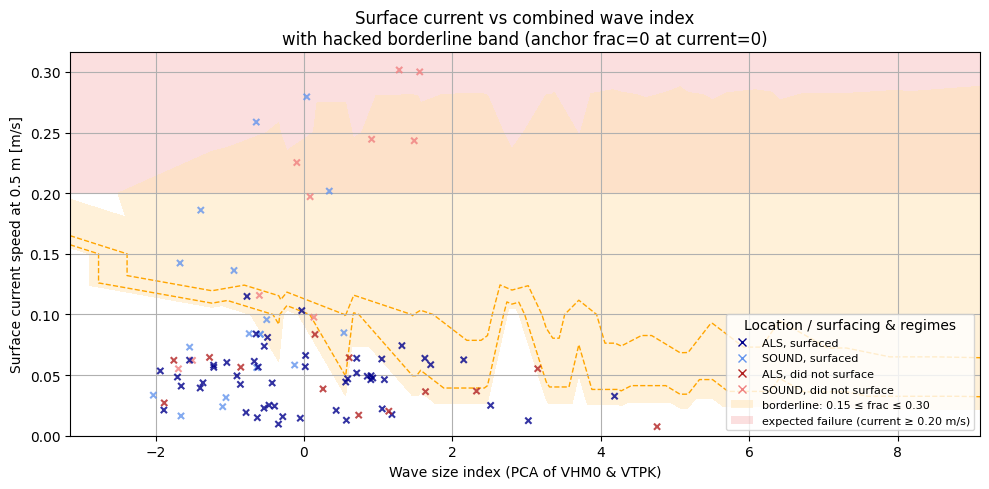

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ----------------------------------------------------
# 1. Real data: build PCA wave index
# ----------------------------------------------------
CSV_FILE = "./data/deployment_data/surfacing_wave_current_copernicus_components.csv"
df = pd.read_csv(CSV_FILE)

def vector_string_to_speed(s):
    if not isinstance(s, str):
        return np.nan
    s = s.strip("[]")
    if not s:
        return np.nan
    arr = np.fromstring(s, sep=" ")
    if arr.size < 2:
        return np.nan
    return float(np.linalg.norm(arr))

df["current0_5m_speed"] = df["current_0.5m"].apply(vector_string_to_speed)
df = df.dropna(subset=["VHM0", "VTPK", "current0_5m_speed", "surfaced", "location"]).reset_index(drop=True)

X = df[["VHM0", "VTPK"]].values
mean = X.mean(axis=0)
std  = X.std(axis=0, ddof=0)
X_std = (X - mean) / std
cov = np.cov(X_std, rowvar=False)
eigvals, eigvecs = np.linalg.eigh(cov)
idx = np.argsort(eigvals)[::-1]
pc1 = eigvecs[:, idx[0]]
df["wave_index"] = X_std @ pc1

# ----------------------------------------------------
# 2. Simulation data: paste list-of-dicts
# ----------------------------------------------------
points = [{'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 0.25, 'frac': 0.03913405495420483}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 0.25, 'frac': 0.051623646960865945}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 0.25, 'frac': 0.035803497085761866}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 0.5, 'frac': 0.23480432972522897}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 0.5, 'frac': 0.18401332223147376}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 0.5, 'frac': 0.20982514571190675}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 0.75, 'frac': 0.3630308076602831}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 0.75, 'frac': 0.2781015820149875}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 0.75, 'frac': 0.305578684429642}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 1.0, 'frac': 0.32389675270607826}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 1.0, 'frac': 0.3630308076602831}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 1.0, 'frac': 0.30308076602830974}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 1.25, 'frac': 0.33638634471273937}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 1.25, 'frac': 0.3946711074104913}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 1.25, 'frac': 0.3813488759367194}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 1.5, 'frac': 0.42714404662781014}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 1.5, 'frac': 0.4054954204829309}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 1.5, 'frac': 0.3680266444629475}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 1.75, 'frac': 0.47626977518734387}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 1.75, 'frac': 0.43713572023313907}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 1.75, 'frac': 0.414654454621149}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 2.0, 'frac': 0.466278101582015}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 2.0, 'frac': 0.4238134887593672}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 2.0, 'frac': 0.4487926727726894}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 0.25, 'frac': 0.01665278934221482}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 0.25, 'frac': 0.025811823480432972}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 0.25, 'frac': 0.013322231473771857}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 0.5, 'frac': 0.19983347210657784}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 0.5, 'frac': 0.1357202331390508}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 0.5, 'frac': 0.16319733555370525}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 0.75, 'frac': 0.3530391340549542}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 0.75, 'frac': 0.23980016652789343}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 0.75, 'frac': 0.2664446294754371}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 1.0, 'frac': 0.3047460449625312}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 1.0, 'frac': 0.33805162364696084}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 1.0, 'frac': 0.27310574521232306}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 1.25, 'frac': 0.3164029975020816}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 1.25, 'frac': 0.373022481265612}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 1.25, 'frac': 0.35387177352206495}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 1.5, 'frac': 0.414654454621149}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 1.5, 'frac': 0.37635303913405493}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 1.5, 'frac': 0.33805162364696084}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 1.75, 'frac': 0.4612822647793505}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 1.75, 'frac': 0.4079933388842631}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 1.75, 'frac': 0.3930058284762698}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 2.0, 'frac': 0.4546211490424646}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 2.0, 'frac': 0.4104912572855953}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 2.0, 'frac': 0.4379683597002498}, {'depth': 10.0, 'current': 0.1, 'Tp': 0.0, 'Hs': 0.0, 'frac': 0.0}, {'depth': 10.0, 'current': 0.12, 'Tp': 0.0, 'Hs': 0.0, 'frac': 0.0}, {'depth': 10.0, 'current': 0.15, 'Tp': 0.0, 'Hs': 0.0, 'frac': 0.0}, {'depth': 10.0, 'current': 0.15, 'Tp': 5.0, 'Hs': 0.25, 'frac': 0.6869275603663614}, {'depth': 10.0, 'current': 0.15, 'Tp': 2.0, 'Hs': 0.25, 'frac': 0.7252289758534555}, {'depth': 10.0, 'current': 0.15, 'Tp': 1.0, 'Hs': 0.25, 'frac': 0.746044962531224}, {'depth': 10.0, 'current': 0.15, 'Tp': 5.0, 'Hs': 0.5, 'frac': 0.6253122398001665}, {'depth': 10.0, 'current': 0.15, 'Tp': 2.0, 'Hs': 0.5, 'frac': 0.6519567027477102}, {'depth': 10.0, 'current': 0.15, 'Tp': 1.0, 'Hs': 0.5, 'frac': 0.6053288925895087}, {'depth': 10.0, 'current': 0.15, 'Tp': 5.0, 'Hs': 0.75, 'frac': 0.5270607826810991}, {'depth': 10.0, 'current': 0.15, 'Tp': 2.0, 'Hs': 0.75, 'frac': 0.5920066611157369}, {'depth': 10.0, 'current': 0.15, 'Tp': 1.0, 'Hs': 0.75, 'frac': 0.5870108243130724}, {'depth': 10.0, 'current': 0.15, 'Tp': 5.0, 'Hs': 1.0, 'frac': 0.5353871773522065}, {'depth': 10.0, 'current': 0.15, 'Tp': 2.0, 'Hs': 1.0, 'frac': 0.5745212323064113}, {'depth': 10.0, 'current': 0.15, 'Tp': 1.0, 'Hs': 1.0, 'frac': 0.5636969192339717}, {'depth': 10.0, 'current': 0.15, 'Tp': 5.0, 'Hs': 1.25, 'frac': 0.5537052456286428}, {'depth': 10.0, 'current': 0.15, 'Tp': 2.0, 'Hs': 1.25, 'frac': 0.5878434637801832}, {'depth': 10.0, 'current': 0.15, 'Tp': 1.0, 'Hs': 1.25, 'frac': 0.5720233139050791}, {'depth': 10.0, 'current': 0.15, 'Tp': 5.0, 'Hs': 1.5, 'frac': 0.559533721898418}, {'depth': 10.0, 'current': 0.15, 'Tp': 2.0, 'Hs': 1.5, 'frac': 0.5828476269775187}, {'depth': 10.0, 'current': 0.15, 'Tp': 1.0, 'Hs': 1.5, 'frac': 0.5886761032472939}, {'depth': 10.0, 'current': 0.15, 'Tp': 5.0, 'Hs': 1.75, 'frac': 0.5711906744379683}, {'depth': 10.0, 'current': 0.15, 'Tp': 2.0, 'Hs': 1.75, 'frac': 0.5828476269775187}, {'depth': 10.0, 'current': 0.15, 'Tp': 1.0, 'Hs': 1.75, 'frac': 0.5770191507077436}, {'depth': 10.0, 'current': 0.15, 'Tp': 5.0, 'Hs': 2.0, 'frac': 0.5803497085761865}, {'depth': 10.0, 'current': 0.15, 'Tp': 2.0, 'Hs': 2.0, 'frac': 0.5861781848459617}, {'depth': 10.0, 'current': 0.15, 'Tp': 1.0, 'Hs': 2.0, 'frac': 0.5803497085761865}, {'depth': 10.0, 'current': 0.2, 'Tp': 5.0, 'Hs': 0.25, 'frac': 0.6727726894254787}, {'depth': 10.0, 'current': 0.2, 'Tp': 2.0, 'Hs': 0.25, 'frac': 0.7160699417152373}, {'depth': 10.0, 'current': 0.2, 'Tp': 1.0, 'Hs': 0.25, 'frac': 0.7035803497085762}, {'depth': 10.0, 'current': 0.2, 'Tp': 5.0, 'Hs': 0.5, 'frac': 0.6353039134054954}, {'depth': 10.0, 'current': 0.2, 'Tp': 2.0, 'Hs': 0.5, 'frac': 0.6361365528726062}, {'depth': 10.0, 'current': 0.2, 'Tp': 1.0, 'Hs': 0.5, 'frac': 0.6236469608659451}, {'depth': 10.0, 'current': 0.2, 'Tp': 5.0, 'Hs': 0.75, 'frac': 0.6036636136552873}, {'depth': 10.0, 'current': 0.2, 'Tp': 2.0, 'Hs': 0.75, 'frac': 0.5845129059117402}, {'depth': 10.0, 'current': 0.2, 'Tp': 1.0, 'Hs': 0.75, 'frac': 0.5736885928393006}, {'depth': 10.0, 'current': 0.2, 'Tp': 5.0, 'Hs': 1.0, 'frac': 0.5703580349708576}, {'depth': 10.0, 'current': 0.2, 'Tp': 2.0, 'Hs': 1.0, 'frac': 0.5620316402997502}, {'depth': 10.0, 'current': 0.2, 'Tp': 1.0, 'Hs': 1.0, 'frac': 0.556203164029975}, {'depth': 10.0, 'current': 0.2, 'Tp': 5.0, 'Hs': 1.25, 'frac': 0.5845129059117402}, {'depth': 10.0, 'current': 0.2, 'Tp': 2.0, 'Hs': 1.25, 'frac': 0.5811823480432973}, {'depth': 10.0, 'current': 0.2, 'Tp': 1.0, 'Hs': 1.25, 'frac': 0.5628642797668609}, {'depth': 10.0, 'current': 0.2, 'Tp': 5.0, 'Hs': 1.5, 'frac': 0.5761865112406328}, {'depth': 10.0, 'current': 0.2, 'Tp': 2.0, 'Hs': 1.5, 'frac': 0.5836802664446294}, {'depth': 10.0, 'current': 0.2, 'Tp': 1.0, 'Hs': 1.5, 'frac': 0.5861781848459617}, {'depth': 10.0, 'current': 0.2, 'Tp': 5.0, 'Hs': 1.75, 'frac': 0.6136552872606161}, {'depth': 10.0, 'current': 0.2, 'Tp': 2.0, 'Hs': 1.75, 'frac': 0.5878434637801832}, {'depth': 10.0, 'current': 0.2, 'Tp': 1.0, 'Hs': 1.75, 'frac': 0.5728559533721899}, {'depth': 10.0, 'current': 0.2, 'Tp': 5.0, 'Hs': 2.0, 'frac': 0.6069941715237303}, {'depth': 10.0, 'current': 0.2, 'Tp': 2.0, 'Hs': 2.0, 'frac': 0.5720233139050791}, {'depth': 10.0, 'current': 0.2, 'Tp': 1.0, 'Hs': 2.0, 'frac': 0.5828476269775187}, {'depth': 10.0, 'current': 0.2, 'Tp': 0.0, 'Hs': 0.0, 'frac': 1.0}, {'depth': 10.0, 'current': 0.25, 'Tp': 5.0, 'Hs': 0.25, 'frac': 0.9825145711906744}, {'depth': 10.0, 'current': 0.25, 'Tp': 2.0, 'Hs': 0.25, 'frac': 0.9783513738551207}, {'depth': 10.0, 'current': 0.25, 'Tp': 1.0, 'Hs': 0.25, 'frac': 0.9883430474604497}, {'depth': 10.0, 'current': 0.25, 'Tp': 5.0, 'Hs': 0.5, 'frac': 0.9084096586178185}, {'depth': 10.0, 'current': 0.25, 'Tp': 2.0, 'Hs': 0.5, 'frac': 0.9250624479600333}, {'depth': 10.0, 'current': 0.25, 'Tp': 1.0, 'Hs': 0.5, 'frac': 0.8800999167360533}, {'depth': 10.0, 'current': 0.25, 'Tp': 5.0, 'Hs': 0.75, 'frac': 0.7660283097418817}, {'depth': 10.0, 'current': 0.25, 'Tp': 2.0, 'Hs': 0.75, 'frac': 0.8026644462947544}, {'depth': 10.0, 'current': 0.25, 'Tp': 1.0, 'Hs': 0.75, 'frac': 0.8043297252289758}, {'depth': 10.0, 'current': 0.25, 'Tp': 5.0, 'Hs': 1.0, 'frac': 0.7826810990840966}, {'depth': 10.0, 'current': 0.25, 'Tp': 2.0, 'Hs': 1.0, 'frac': 0.7410491257285595}, {'depth': 10.0, 'current': 0.25, 'Tp': 1.0, 'Hs': 1.0, 'frac': 0.7385512073272273}, {'depth': 10.0, 'current': 0.25, 'Tp': 2.0, 'Hs': 1.25, 'frac': 0.7127393838467944}, {'depth': 10.0, 'current': 0.25, 'Tp': 1.0, 'Hs': 1.25, 'frac': 0.7293921731890092}, {'depth': 10.0, 'current': 0.25, 'Tp': 5.0, 'Hs': 1.5, 'frac': 0.7252289758534555}, {'depth': 10.0, 'current': 0.25, 'Tp': 2.0, 'Hs': 1.5, 'frac': 0.7318900915903414}, {'depth': 10.0, 'current': 0.25, 'Tp': 1.0, 'Hs': 1.5, 'frac': 0.736053288925895}, {'depth': 10.0, 'current': 0.25, 'Tp': 5.0, 'Hs': 1.75, 'frac': 0.736053288925895}, {'depth': 10.0, 'current': 0.25, 'Tp': 2.0, 'Hs': 1.75, 'frac': 0.7327227310574521}, {'depth': 10.0, 'current': 0.25, 'Tp': 1.0, 'Hs': 1.75, 'frac': 0.7194004995836802}, {'depth': 10.0, 'current': 0.25, 'Tp': 5.0, 'Hs': 2.0, 'frac': 0.7177352206494588}, {'depth': 10.0, 'current': 0.25, 'Tp': 2.0, 'Hs': 2.0, 'frac': 0.7077435470441299}, {'depth': 10.0, 'current': 0.25, 'Tp': 1.0, 'Hs': 2.0, 'frac': 0.7069109075770191}, {'depth': 10.0, 'current': 0.25, 'Tp': 0.0, 'Hs': 0.0, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 0.0, 'Hs': 0.0, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 5.0, 'Hs': 0.25, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 2.0, 'Hs': 0.25, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 1.0, 'Hs': 0.25, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 5.0, 'Hs': 0.5, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 2.0, 'Hs': 0.5, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 1.0, 'Hs': 0.5, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 5.0, 'Hs': 0.75, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 2.0, 'Hs': 0.75, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 1.0, 'Hs': 0.75, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 5.0, 'Hs': 1.0, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 2.0, 'Hs': 1.0, 'frac': 0.9983347210657785}, {'depth': 10.0, 'current': 0.3, 'Tp': 1.0, 'Hs': 1.0, 'frac': 0.9983347210657785}, {'depth': 10.0, 'current': 0.3, 'Tp': 5.0, 'Hs': 1.25, 'frac': 0.9958368026644463}, {'depth': 10.0, 'current': 0.3, 'Tp': 2.0, 'Hs': 1.25, 'frac': 0.9966694421315571}, {'depth': 10.0, 'current': 0.3, 'Tp': 1.0, 'Hs': 1.25, 'frac': 0.9925062447960034}, {'depth': 10.0, 'current': 0.3, 'Tp': 5.0, 'Hs': 1.5, 'frac': 0.9958368026644463}, {'depth': 10.0, 'current': 0.3, 'Tp': 2.0, 'Hs': 1.5, 'frac': 0.9833472106577852}, {'depth': 10.0, 'current': 0.3, 'Tp': 1.0, 'Hs': 1.5, 'frac': 0.9975020815986678}, {'depth': 10.0, 'current': 0.3, 'Tp': 5.0, 'Hs': 1.75, 'frac': 0.97751873438801}, {'depth': 10.0, 'current': 0.3, 'Tp': 2.0, 'Hs': 1.75, 'frac': 0.9858451290591174}, {'depth': 10.0, 'current': 0.3, 'Tp': 1.0, 'Hs': 1.75, 'frac': 0.974188176519567}, {'depth': 10.0, 'current': 0.3, 'Tp': 5.0, 'Hs': 2.0, 'frac': 0.9567027477102414}, {'depth': 10.0, 'current': 0.3, 'Tp': 2.0, 'Hs': 2.0, 'frac': 0.9800166527893422}, {'depth': 10.0, 'current': 0.3, 'Tp': 1.0, 'Hs': 2.0, 'frac': 0.9625312239800167}]

sim = pd.DataFrame(points)
sim = sim[sim["depth"] == 10.0].copy()

# Map (Hs, Tp) onto same PCA axis
sim_X = sim[["Hs", "Tp"]].values
sim_X_std = (sim_X - mean) / std
sim["wave_index"] = sim_X_std @ pc1

# ----------------------------------------------------
# 3. Modelling hack: add synthetic line at current=0 with frac=0
# ----------------------------------------------------
# Use unique (Hs, Tp) combos with non-zero waves
ht_unique = sim[(sim["Hs"] > 0) & (sim["Tp"] > 0)][["Hs", "Tp"]].drop_duplicates()

anchor = ht_unique.copy()
anchor["depth"] = 10.0
anchor["current"] = 0.0
anchor["frac"] = 0.0

# Map to wave_index using SAME standardization and pc1
anchor_X = anchor[["Hs", "Tp"]].values
anchor_X_std = (anchor_X - mean) / std
anchor["wave_index"] = anchor_X_std @ pc1

sim_aug = pd.concat([sim, anchor], ignore_index=True)

# ----------------------------------------------------
# 4. Colors for real scatter points
# ----------------------------------------------------
COLORS = {
    "YES": {"ALS": "darkblue",   "SOUND": "cornflowerblue"},
    "NO":  {"ALS": "firebrick",  "SOUND": "lightcoral"},
}
def choose_color(row):
    return COLORS.get(row["surfaced"], {}).get(row["location"], "grey")

df["color"] = df.apply(choose_color, axis=1)

# ----------------------------------------------------
# 5. Plot
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(
    df["wave_index"],
    df["current0_5m_speed"],
    c=df["color"],
    s=20,
    alpha=0.8,
    marker="x",
    zorder=3,
)

ymin, ymax = ax.get_ylim()
ymax = max(ymax, 0.3)
ax.set_ylim(0.0, ymax)

triang = tri.Triangulation(sim_aug["wave_index"], sim_aug["current"])

# borderline band 0.15–0.30
ax.tricontourf(
    triang,
    sim_aug["frac"],
    levels=[0.1, 0.90],
    colors=["moccasin"],
    alpha=0.5,
    zorder=0,
)
ax.tricontour(
    triang,
    sim_aug["frac"],
    levels=[0.15, 0.30],
    colors="orange",
    linestyles="--",
    linewidths=1.0,
    zorder=1,
)

# simple expected-failure band (still horizontal for now)
ax.axhspan(
    0.20, ymax,
    facecolor="lightcoral",
    alpha=0.25,
    zorder=-1,
)

ax.set_xlabel("Wave size index (PCA of VHM0 & VTPK)")
ax.set_ylabel("Surface current speed at 0.5 m [m/s]")
ax.set_title("Surface current vs combined wave index\nwith hacked borderline band (anchor frac=0 at current=0)")

# Legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

point_handles = [
    Line2D([0], [0], marker='x', linestyle='None', color="darkblue",       label="ALS, surfaced"),
    Line2D([0], [0], marker='x', linestyle='None', color="cornflowerblue", label="SOUND, surfaced"),
    Line2D([0], [0], marker='x', linestyle='None', color="firebrick",      label="ALS, did not surface"),
    Line2D([0], [0], marker='x', linestyle='None', color="lightcoral",     label="SOUND, did not surface"),
]

band_handles = [
    Patch(facecolor="moccasin",   alpha=0.5,  label="borderline: 0.15 ≤ frac ≤ 0.30"),
    Patch(facecolor="lightcoral", alpha=0.25, label="expected failure (current ≥ 0.20 m/s)"),
]

ax.legend(handles=point_handles + band_handles, fontsize=8, title="Location / surfacing & regimes")
ax.grid(True)
fig.tight_layout()
plt.show()


[0.16861995 1.85335807]


/tmp/ipykernel_104778/821785976.py:97: RuntimeWarning: invalid value encountered in divide
  frac_smooth = np.where(weights_s > 1e-3, data_s / weights_s, np.nan)


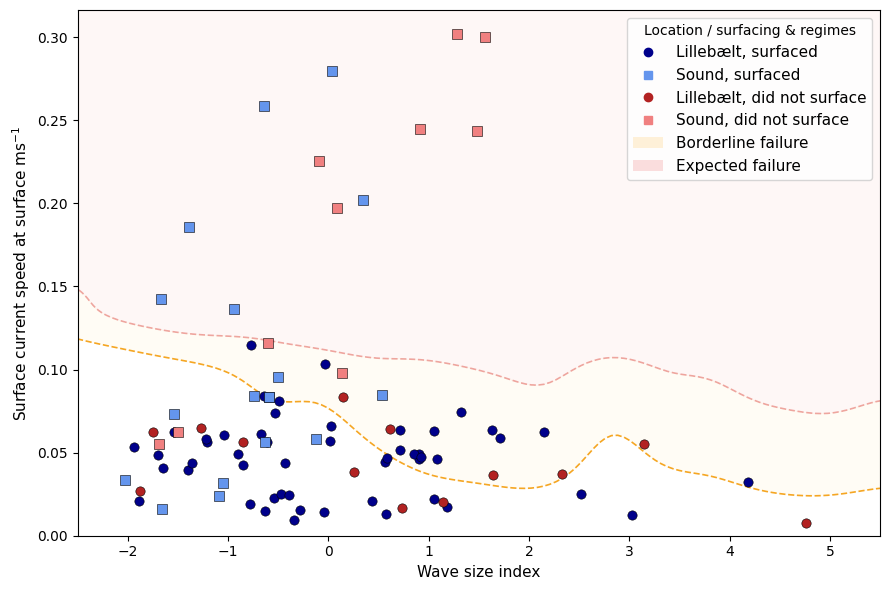

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Try importing gaussian_filter
try:
    from scipy.ndimage import gaussian_filter
except Exception as e:
    print("SciPy not available:", e)
    raise

# ----------------------------------------------------
# 1. Real data: build PCA wave index (reuse previous logic)
# ----------------------------------------------------

df = pd.read_csv(CSV_FILE)

def vector_string_to_speed(s):
    if not isinstance(s, str):
        return np.nan
    s = s.strip("[]")
    if not s:
        return np.nan
    arr = np.fromstring(s, sep=" ")
    if arr.size < 2:
        return np.nan
    return float(np.linalg.norm(arr))

df["current0_5m_speed"] = df["current_0.5m"].apply(vector_string_to_speed)
df = df.dropna(subset=["VHM0", "VTPK", "current0_5m_speed", "surfaced", "location"]).reset_index(drop=True)

X = df[["VHM0", "VTPK"]].values
mean = X.mean(axis=0)
std  = X.std(axis=0, ddof=0)
X_std = (X - mean) / std
cov = np.cov(X_std, rowvar=False)
eigvals, eigvecs = np.linalg.eigh(cov)
print(eigvals)
idx = np.argsort(eigvals)[::-1]
pc1 = eigvecs[:, idx[0]]
df["wave_index"] = X_std @ pc1

# ----------------------------------------------------
# 2. Simulation data and modelling hack (anchor at current=0, frac=0)
# ----------------------------------------------------
# NOTE: I'm reusing the shorter portion of points if necessary,
# but here I assume the full list is still fine from previous step.
points = [{'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 0.25, 'frac': 0.03913405495420483}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 0.25, 'frac': 0.051623646960865945}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 0.25, 'frac': 0.035803497085761866}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 0.5, 'frac': 0.23480432972522897}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 0.5, 'frac': 0.18401332223147376}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 0.5, 'frac': 0.20982514571190675}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 0.75, 'frac': 0.3630308076602831}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 0.75, 'frac': 0.2781015820149875}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 0.75, 'frac': 0.305578684429642}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 1.0, 'frac': 0.32389675270607826}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 1.0, 'frac': 0.3630308076602831}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 1.0, 'frac': 0.30308076602830974}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 1.25, 'frac': 0.33638634471273937}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 1.25, 'frac': 0.3946711074104913}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 1.25, 'frac': 0.3813488759367194}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 1.5, 'frac': 0.42714404662781014}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 1.5, 'frac': 0.4054954204829309}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 1.5, 'frac': 0.3680266444629475}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 1.75, 'frac': 0.47626977518734387}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 1.75, 'frac': 0.43713572023313907}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 1.75, 'frac': 0.414654454621149}, {'depth': 10.0, 'current': 0.1, 'Tp': 5.0, 'Hs': 2.0, 'frac': 0.466278101582015}, {'depth': 10.0, 'current': 0.1, 'Tp': 2.0, 'Hs': 2.0, 'frac': 0.4238134887593672}, {'depth': 10.0, 'current': 0.1, 'Tp': 1.0, 'Hs': 2.0, 'frac': 0.4487926727726894}, {'depth': 10.0, 'current': 0.1, 'Tp': 0.0, 'Hs': 0.0, 'frac': 0.0}, {'depth': 10.0, 'current': 0.12, 'Tp': 0.0, 'Hs': 0.0, 'frac': 0.0}, {'depth': 10.0, 'current': 0.15, 'Tp': 0.0, 'Hs': 0.0, 'frac': 0.0}, {'depth': 10.0, 'current': 0.15, 'Tp': 5.0, 'Hs': 0.25, 'frac': 0.6869275603663614}, {'depth': 10.0, 'current': 0.15, 'Tp': 2.0, 'Hs': 0.25, 'frac': 0.7252289758534555}, {'depth': 10.0, 'current': 0.15, 'Tp': 1.0, 'Hs': 0.25, 'frac': 0.746044962531224}, {'depth': 10.0, 'current': 0.15, 'Tp': 5.0, 'Hs': 0.5, 'frac': 0.6253122398001665}, {'depth': 10.0, 'current': 0.15, 'Tp': 2.0, 'Hs': 0.5, 'frac': 0.6519567027477102}, {'depth': 10.0, 'current': 0.15, 'Tp': 1.0, 'Hs': 0.5, 'frac': 0.6053288925895087}, {'depth': 10.0, 'current': 0.15, 'Tp': 5.0, 'Hs': 0.75, 'frac': 0.5270607826810991}, {'depth': 10.0, 'current': 0.15, 'Tp': 2.0, 'Hs': 0.75, 'frac': 0.5920066611157369}, {'depth': 10.0, 'current': 0.15, 'Tp': 1.0, 'Hs': 0.75, 'frac': 0.5870108243130724}, {'depth': 10.0, 'current': 0.15, 'Tp': 5.0, 'Hs': 1.0, 'frac': 0.5353871773522065}, {'depth': 10.0, 'current': 0.15, 'Tp': 2.0, 'Hs': 1.0, 'frac': 0.5745212323064113}, {'depth': 10.0, 'current': 0.15, 'Tp': 1.0, 'Hs': 1.0, 'frac': 0.5636969192339717}, {'depth': 10.0, 'current': 0.15, 'Tp': 5.0, 'Hs': 1.25, 'frac': 0.5537052456286428}, {'depth': 10.0, 'current': 0.15, 'Tp': 2.0, 'Hs': 1.25, 'frac': 0.5878434637801832}, {'depth': 10.0, 'current': 0.15, 'Tp': 1.0, 'Hs': 1.25, 'frac': 0.5720233139050791}, {'depth': 10.0, 'current': 0.15, 'Tp': 5.0, 'Hs': 1.5, 'frac': 0.559533721898418}, {'depth': 10.0, 'current': 0.15, 'Tp': 2.0, 'Hs': 1.5, 'frac': 0.5828476269775187}, {'depth': 10.0, 'current': 0.15, 'Tp': 1.0, 'Hs': 1.5, 'frac': 0.5886761032472939}, {'depth': 10.0, 'current': 0.15, 'Tp': 5.0, 'Hs': 1.75, 'frac': 0.5711906744379683}, {'depth': 10.0, 'current': 0.15, 'Tp': 2.0, 'Hs': 1.75, 'frac': 0.5828476269775187}, {'depth': 10.0, 'current': 0.15, 'Tp': 1.0, 'Hs': 1.75, 'frac': 0.5770191507077436}, {'depth': 10.0, 'current': 0.15, 'Tp': 5.0, 'Hs': 2.0, 'frac': 0.5803497085761865}, {'depth': 10.0, 'current': 0.15, 'Tp': 2.0, 'Hs': 2.0, 'frac': 0.5861781848459617}, {'depth': 10.0, 'current': 0.15, 'Tp': 1.0, 'Hs': 2.0, 'frac': 0.5803497085761865}, {'depth': 10.0, 'current': 0.2, 'Tp': 5.0, 'Hs': 0.25, 'frac': 0.6727726894254787}, {'depth': 10.0, 'current': 0.2, 'Tp': 2.0, 'Hs': 0.25, 'frac': 0.7160699417152373}, {'depth': 10.0, 'current': 0.2, 'Tp': 1.0, 'Hs': 0.25, 'frac': 0.7035803497085762}, {'depth': 10.0, 'current': 0.2, 'Tp': 5.0, 'Hs': 0.5, 'frac': 0.6353039134054954}, {'depth': 10.0, 'current': 0.2, 'Tp': 2.0, 'Hs': 0.5, 'frac': 0.6361365528726062}, {'depth': 10.0, 'current': 0.2, 'Tp': 1.0, 'Hs': 0.5, 'frac': 0.6236469608659451}, {'depth': 10.0, 'current': 0.2, 'Tp': 5.0, 'Hs': 0.75, 'frac': 0.6036636136552873}, {'depth': 10.0, 'current': 0.2, 'Tp': 2.0, 'Hs': 0.75, 'frac': 0.5845129059117402}, {'depth': 10.0, 'current': 0.2, 'Tp': 1.0, 'Hs': 0.75, 'frac': 0.5736885928393006}, {'depth': 10.0, 'current': 0.2, 'Tp': 5.0, 'Hs': 1.0, 'frac': 0.5703580349708576}, {'depth': 10.0, 'current': 0.2, 'Tp': 2.0, 'Hs': 1.0, 'frac': 0.5620316402997502}, {'depth': 10.0, 'current': 0.2, 'Tp': 1.0, 'Hs': 1.0, 'frac': 0.556203164029975}, {'depth': 10.0, 'current': 0.2, 'Tp': 5.0, 'Hs': 1.25, 'frac': 0.5845129059117402}, {'depth': 10.0, 'current': 0.2, 'Tp': 2.0, 'Hs': 1.25, 'frac': 0.5811823480432973}, {'depth': 10.0, 'current': 0.2, 'Tp': 1.0, 'Hs': 1.25, 'frac': 0.5628642797668609}, {'depth': 10.0, 'current': 0.2, 'Tp': 5.0, 'Hs': 1.5, 'frac': 0.5761865112406328}, {'depth': 10.0, 'current': 0.2, 'Tp': 2.0, 'Hs': 1.5, 'frac': 0.5836802664446294}, {'depth': 10.0, 'current': 0.2, 'Tp': 1.0, 'Hs': 1.5, 'frac': 0.5861781848459617}, {'depth': 10.0, 'current': 0.2, 'Tp': 5.0, 'Hs': 1.75, 'frac': 0.6136552872606161}, {'depth': 10.0, 'current': 0.2, 'Tp': 2.0, 'Hs': 1.75, 'frac': 0.5878434637801832}, {'depth': 10.0, 'current': 0.2, 'Tp': 1.0, 'Hs': 1.75, 'frac': 0.5728559533721899}, {'depth': 10.0, 'current': 0.2, 'Tp': 5.0, 'Hs': 2.0, 'frac': 0.6069941715237303}, {'depth': 10.0, 'current': 0.2, 'Tp': 2.0, 'Hs': 2.0, 'frac': 0.5720233139050791}, {'depth': 10.0, 'current': 0.2, 'Tp': 1.0, 'Hs': 2.0, 'frac': 0.5828476269775187}, {'depth': 10.0, 'current': 0.2, 'Tp': 0.0, 'Hs': 0.0, 'frac': 1.0}, {'depth': 10.0, 'current': 0.25, 'Tp': 5.0, 'Hs': 0.25, 'frac': 0.9825145711906744}, {'depth': 10.0, 'current': 0.25, 'Tp': 2.0, 'Hs': 0.25, 'frac': 0.9783513738551207}, {'depth': 10.0, 'current': 0.25, 'Tp': 1.0, 'Hs': 0.25, 'frac': 0.9883430474604497}, {'depth': 10.0, 'current': 0.25, 'Tp': 5.0, 'Hs': 0.5, 'frac': 0.9084096586178185}, {'depth': 10.0, 'current': 0.25, 'Tp': 2.0, 'Hs': 0.5, 'frac': 0.9250624479600333}, {'depth': 10.0, 'current': 0.25, 'Tp': 1.0, 'Hs': 0.5, 'frac': 0.8800999167360533}, {'depth': 10.0, 'current': 0.25, 'Tp': 5.0, 'Hs': 0.75, 'frac': 0.7660283097418817}, {'depth': 10.0, 'current': 0.25, 'Tp': 2.0, 'Hs': 0.75, 'frac': 0.8026644462947544}, {'depth': 10.0, 'current': 0.25, 'Tp': 1.0, 'Hs': 0.75, 'frac': 0.8043297252289758}, {'depth': 10.0, 'current': 0.25, 'Tp': 5.0, 'Hs': 1.0, 'frac': 0.7826810990840966}, {'depth': 10.0, 'current': 0.25, 'Tp': 2.0, 'Hs': 1.0, 'frac': 0.7410491257285595}, {'depth': 10.0, 'current': 0.25, 'Tp': 1.0, 'Hs': 1.0, 'frac': 0.7385512073272273}, {'depth': 10.0, 'current': 0.25, 'Tp': 2.0, 'Hs': 1.25, 'frac': 0.7127393838467944}, {'depth': 10.0, 'current': 0.25, 'Tp': 1.0, 'Hs': 1.25, 'frac': 0.7293921731890092}, {'depth': 10.0, 'current': 0.25, 'Tp': 5.0, 'Hs': 1.5, 'frac': 0.7252289758534555}, {'depth': 10.0, 'current': 0.25, 'Tp': 2.0, 'Hs': 1.5, 'frac': 0.7318900915903414}, {'depth': 10.0, 'current': 0.25, 'Tp': 1.0, 'Hs': 1.5, 'frac': 0.736053288925895}, {'depth': 10.0, 'current': 0.25, 'Tp': 5.0, 'Hs': 1.75, 'frac': 0.736053288925895}, {'depth': 10.0, 'current': 0.25, 'Tp': 2.0, 'Hs': 1.75, 'frac': 0.7327227310574521}, {'depth': 10.0, 'current': 0.25, 'Tp': 1.0, 'Hs': 1.75, 'frac': 0.7194004995836802}, {'depth': 10.0, 'current': 0.25, 'Tp': 5.0, 'Hs': 2.0, 'frac': 0.7177352206494588}, {'depth': 10.0, 'current': 0.25, 'Tp': 2.0, 'Hs': 2.0, 'frac': 0.7077435470441299}, {'depth': 10.0, 'current': 0.25, 'Tp': 1.0, 'Hs': 2.0, 'frac': 0.7069109075770191}, {'depth': 10.0, 'current': 0.25, 'Tp': 0.0, 'Hs': 0.0, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 0.0, 'Hs': 0.0, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 5.0, 'Hs': 0.25, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 2.0, 'Hs': 0.25, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 1.0, 'Hs': 0.25, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 5.0, 'Hs': 0.5, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 2.0, 'Hs': 0.5, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 1.0, 'Hs': 0.5, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 5.0, 'Hs': 0.75, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 2.0, 'Hs': 0.75, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 1.0, 'Hs': 0.75, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 5.0, 'Hs': 1.0, 'frac': 1.0}, {'depth': 10.0, 'current': 0.3, 'Tp': 2.0, 'Hs': 1.0, 'frac': 0.9983347210657785}, {'depth': 10.0, 'current': 0.3, 'Tp': 1.0, 'Hs': 1.0, 'frac': 0.9983347210657785}, {'depth': 10.0, 'current': 0.3, 'Tp': 5.0, 'Hs': 1.25, 'frac': 0.9958368026644463}, {'depth': 10.0, 'current': 0.3, 'Tp': 2.0, 'Hs': 1.25, 'frac': 0.9966694421315571}, {'depth': 10.0, 'current': 0.3, 'Tp': 1.0, 'Hs': 1.25, 'frac': 0.9925062447960034}, {'depth': 10.0, 'current': 0.3, 'Tp': 5.0, 'Hs': 1.5, 'frac': 0.9958368026644463}, {'depth': 10.0, 'current': 0.3, 'Tp': 2.0, 'Hs': 1.5, 'frac': 0.9833472106577852}, {'depth': 10.0, 'current': 0.3, 'Tp': 1.0, 'Hs': 1.5, 'frac': 0.9975020815986678}, {'depth': 10.0, 'current': 0.3, 'Tp': 5.0, 'Hs': 1.75, 'frac': 0.97751873438801}, {'depth': 10.0, 'current': 0.3, 'Tp': 2.0, 'Hs': 1.75, 'frac': 0.9858451290591174}, {'depth': 10.0, 'current': 0.3, 'Tp': 1.0, 'Hs': 1.75, 'frac': 0.974188176519567}, {'depth': 10.0, 'current': 0.3, 'Tp': 5.0, 'Hs': 2.0, 'frac': 0.9567027477102414}, {'depth': 10.0, 'current': 0.3, 'Tp': 2.0, 'Hs': 2.0, 'frac': 0.9800166527893422}, {'depth': 10.0, 'current': 0.3, 'Tp': 1.0, 'Hs': 2.0, 'frac': 0.9625312239800167}]

sim = pd.DataFrame(points)
sim = sim[sim["depth"] == 10.0].copy()

sim_X = sim[["Hs", "Tp"]].values
sim_X_std = (sim_X - mean) / std
sim["wave_index"] = sim_X_std @ pc1

# modelling hack anchors
ht_unique = sim[(sim["Hs"] > 0) & (sim["Tp"] > 0)][["Hs", "Tp"]].drop_duplicates()
anchor = ht_unique.copy()
anchor["depth"] = 10.0
anchor["current"] = 0.0
anchor["frac"] = 0.0
anchor_X = anchor[["Hs", "Tp"]].values
anchor_X_std = (anchor_X - mean) / std
anchor["wave_index"] = anchor_X_std @ pc1

sim_aug = pd.concat([sim, anchor], ignore_index=True)

# ----------------------------------------------------
# 3. Build a regular grid in (wave_index, current) and interpolate
# ----------------------------------------------------
w_min, w_max = sim_aug["wave_index"].min(), sim_aug["wave_index"].max()
c_min, c_max = 0.0, sim_aug["current"].max()

nw, nc = 200, 200
w_grid = np.linspace(w_min, w_max, nw)
c_grid = np.linspace(c_min, c_max, nc)
Wg, Cg = np.meshgrid(w_grid, c_grid)

triang = tri.Triangulation(sim_aug["wave_index"], sim_aug["current"])
interp = tri.LinearTriInterpolator(triang, sim_aug["frac"])
frac_grid = interp(Wg, Cg)

# ----------------------------------------------------
# 4. Heavy Gaussian smoothing on frac_grid
# ----------------------------------------------------
mask = np.isfinite(frac_grid)
data = np.where(mask, frac_grid, 0.0)
weights = mask.astype(float)

sigma = 5.0  # heavy smoothing
data_s = gaussian_filter(data, sigma=sigma)
weights_s = gaussian_filter(weights, sigma=sigma)
frac_smooth = np.where(weights_s > 1e-3, data_s / weights_s, np.nan)

# ----------------------------------------------------
# 5. Prepare real scatter colours
# ----------------------------------------------------
COLORS = {
    "YES": {"ALS": "darkblue",   "SOUND": "cornflowerblue"},
    "NO":  {"ALS": "firebrick",  "SOUND": "lightcoral"},
}

MARKERS = {"ALS": "o", "SOUND": "s"}

# 6. Plot with smoothed orange band
# ----------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

# --- scatter: loop over surfaced / location to apply color + marker ---
for surfaced in ["YES", "NO"]:
    for loc in ["ALS", "SOUND"]:
        m = (df["surfaced"] == surfaced) & (df["location"] == loc)
        if not m.any():
            continue
        ax.scatter(
            df.loc[m, "wave_index"],
            df.loc[m, "current0_5m_speed"],
            color=COLORS[surfaced][loc],
            marker=MARKERS[loc],
            s=45,
            alpha=1.0,
            edgecolors="k",
            linewidths=0.4,
            zorder=3,
        )

# Limits
ymin, ymax = ax.get_ylim()
ymax = max(ymax, 0.3)
ax.set_ylim(0.0, ymax)
ymin, ymax = ax.get_ylim()
ymax = max(ymax, 0.3)
ax.set_ylim(0.0, ymax)

BORDER_FILL   = "#fff3cf"   # very light warm yellow
BORDER_LINE   = "#f5a623"   # warm orange line
FAIL_FILL     = "#fde0dd"   # pale rose
FAIL_LINE     = "#d73027"   # stronger red line if you ever contour it

# Smoothed borderline band 0.15–0.30
cf = ax.contourf(
    Wg, Cg, frac_smooth,
    levels=[0.1, 0.30],
    colors=BORDER_FILL,
    alpha=0.2,
    zorder=-1,
)

cf = ax.contourf(
    Wg, Cg, frac_smooth,
    levels=[0.3, 1.0],
    colors=FAIL_FILL,
    alpha=0.25,
    zorder=0,
)

cl = ax.contour(
    Wg, Cg, frac_smooth,
    levels=[0.30],
    colors=FAIL_LINE,
    alpha = 0.4,
    linestyles="--",
    linewidths=1.2,
    zorder=1,
)

cl = ax.contour(
    Wg, Cg, frac_smooth,
    levels=[0.1],
    colors=BORDER_LINE,
    linestyles="--",
    linewidths=1.2,
    zorder=1,
)


# Expected-failure band still horizontal
ax.axhspan(
    0.30, ymax,
    facecolor=FAIL_FILL,
    alpha=0.25,
    zorder=-1,
)

FONTSIZE = 11

ax.set_xlabel("Wave size index", fontsize = FONTSIZE)
ax.set_ylabel("Surface current speed at surface ms$^{-1}$", fontsize = FONTSIZE)
#ax.set_title("Surface current vs combined wave index\nwith heavily smoothed borderline band")

# Legend
point_handles = [
    Line2D([0], [0], marker='o', linestyle='None', color="darkblue",       label="Lillebælt, surfaced"),
    Line2D([0], [0], marker='s', linestyle='None', color="cornflowerblue", label="Sound, surfaced"),
    Line2D([0], [0], marker='o', linestyle='None', color="firebrick",      label="Lillebælt, did not surface"),
    Line2D([0], [0], marker='s', linestyle='None', color="lightcoral",     label="Sound, did not surface"),
]
band_handles = [
    Patch(facecolor="moccasin",   alpha=0.5,  label="Borderline failure"),
    Patch(facecolor="lightcoral", alpha=0.25, label="Expected failure"),
]
ax.legend(handles=point_handles + band_handles, loc = "upper right", fontsize = FONTSIZE, title="Location / surfacing & regimes")

ax.set_xlim(-2.5,5.5)
fig.tight_layout()
plt.savefig("real_results2.png", dpi = 200)
plt.show()


moordyn/results/correct/waves_4_plot/40m_0.05ms_dt5e-06_T1193s__None.pkl
40m_0.05ms_dt5e-06_T1193s__None.pkl
0.0
moordyn/results/correct/waves_4_plot/40m_0.08ms_dt1e-05_T933s__Hs_3.25m_Fp_0.20Hz_eta.pkl
0.5174708818635607
moordyn/results/correct/waves_4_plot/40m_0.08ms_dt1e-05_T933s__Hs_3.50m_Fp_0.20Hz_eta.pkl
0.47753743760399336
moordyn/results/correct/waves_4_plot/40m_0.08ms_dt1e-05_T933s__Hs_3.75m_Fp_0.20Hz_eta.pkl
0.47088186356073214
moordyn/results/correct/waves_4_plot/40m_0.08ms_dt1e-05_T933s__None.pkl
40m_0.08ms_dt1e-05_T933s__None.pkl
0.0
moordyn/results/correct/waves_4_plot/40m_0.10ms_dt1e-04_T846s__Hs_0.25m_Fp_0.20Hz_eta.pkl
0.03327787021630613
moordyn/results/correct/waves_4_plot/40m_0.10ms_dt1e-04_T846s__Hs_0.25m_Fp_0.50Hz_eta.pkl
0.11148086522462564
moordyn/results/correct/waves_4_plot/40m_0.10ms_dt1e-04_T846s__Hs_0.25m_Fp_1.00Hz_eta.pkl
0.10482529118136441
moordyn/results/correct/waves_4_plot/40m_0.10ms_dt1e-04_T846s__Hs_0.50m_Fp_0.20Hz_eta.pkl
0.2762063227953411
moordyn/

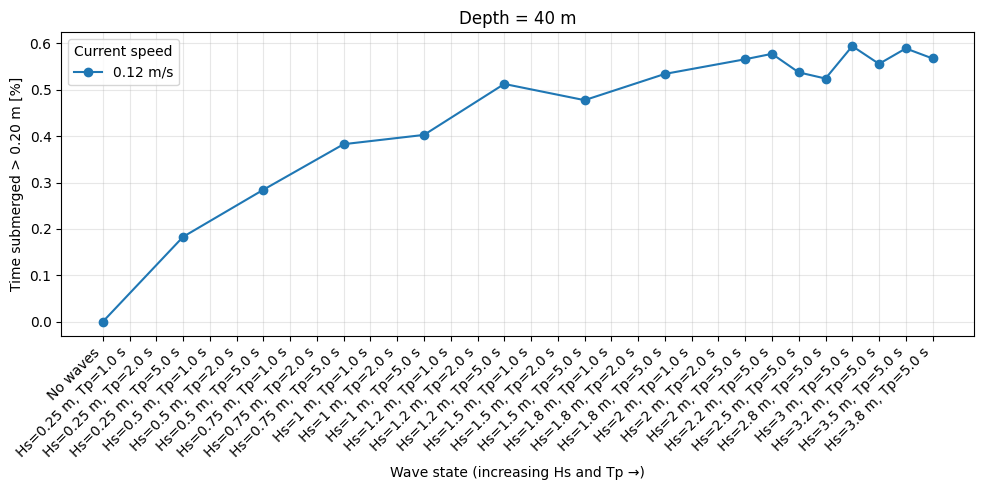

In [9]:
import re
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# ---------- CONFIG ----------
BASE_DIR = Path("./moordyn/results/correct/waves_4_plot")  # adjust if your files live elsewhere
DEPTH = 40         # depth to plot, e.g. 40 m
Z_THRESHOLD = -0.20   # "below 20 cm under the water line" (assuming z>0 is up)


# ---------- HELPERS ----------

fname_re = re.compile(
    r"(?P<depth>\d+)m_"
    r"(?P<current>[\d.]+)ms_"
    r"dt(?P<dt>[\deE+-]+)_"
    r"T(?P<T>\d+)s__"
    r"Hs_(?P<Hs>[\d.]+)m_"
    r"Fp_(?P<Fp>[\d.]+)Hz_eta\.pkl$"
)


def final_heave_perc(res, z_thres = - 0.2):
    time = res['time_hist']  # (N,)
    state = res['state_hist']
    try:# (N,12)
        waves = res['waves']
    except:
        waves = np.zeros_like(time)
    #print(np.max(time))
    if np.max(time) > 200:
        last_60 = np.argmin(np.abs(time - (time[-1]-60)))

        heave = state[:, 2]
        last_heaves = heave[last_60:]
        #print(np.shape(last_heaves))
        last_waves = waves[last_60:]
        #print(last_heaves)
        last_elevations =  last_heaves - last_waves
        #print(last_waves[:10], last_heaves[:10], last_elevations[:10])
        #last_elevations = last_heaves
        #(last_elevations < z_thres)
        percentage = 1-((np.count_nonzero(last_elevations > z_thres))/np.shape(last_heaves)[0])
    else:
        percentage = None
    return percentage

def get_depth_cs_t_hs(file_name):
    parts = file_name.split("_")
    depth = float(parts[0][:-1])   # '40m' -> 40
    cs = float(parts[1][:-2])      # '0.10ms' -> 0.10

    if "None" in file_name:
        # No waves case
        Hs = 0.0
        T = 0.0
        print(file_name)
    else:
        # Wave case: ..._Hs_1.00m_Fp_0.20Hz_eta.pkl
        # parts example:
        # ['40m','0.10ms','dt1e-04','T846s','','Hs','1.00m','Fp','0.20Hz','eta.pkl']
        T = 1.0 / float(parts[-2][:-2])   # '0.20Hz' -> 0.20 -> Tp = 1/Fp
        Hs = float(parts[-4][:-1])        # '1.00m'  -> 1.00

    return {
        "depth": depth,
        "current": cs,
        "Tp": T,
        "Hs": Hs,
    }



# ---------- MAIN LOGIC FOR ONE DEPTH ----------

def plot_submergence_vs_wave_for_depth(depth: float, base_dir: Path):
    files = sorted(base_dir.glob(f"{int(depth)}m_*.pkl"))
    if not files:
        raise FileNotFoundError(f"No files found for depth={depth} m in {base_dir}")

    # Collect per-file stats
    records = []
    for path in files:
        print(path)
        dict_row = get_depth_cs_t_hs(str(path).split("/")[-1])
        with open(path, "rb") as f:
            D = pickle.load(f)
            percentage = final_heave_perc(D)

            if percentage is not None:
                dict_row["frac"] = percentage
                records.append(dict_row)
            print(percentage)


    # Group by current speed
    by_current = {}
    for rec in records:
        by_current.setdefault(rec["current"], []).append(rec)

    #print(records)
    #print(by_current)
    fig, ax = plt.subplots(figsize=(10, 5))

    # Build a single ordering of "increasing waves":
    # sort by Hs ascending, then by Tp ascending (i.e. lower Fp).
    # We'll use integer x positions with text labels.
    # First, gather unique (Hs, Tp) combos:
    wave_states = {}
    for rec in records:
        key = (rec["Hs"], rec["Tp"])
        wave_states.setdefault(key, None)

    wave_keys = sorted(wave_states.keys(), key=lambda k: (k[0], k[1]))  # (Hs, Tp)
    x_positions = {key: i for i, key in enumerate(wave_keys)}

    # Plot one line per current
    for current, recs in sorted(by_current.items()):
        # Sort recs according to our global wave ordering
        if current == 0.12:
            recs_sorted = sorted(recs, key=lambda r: (r["Hs"], r["Tp"]))
            xs = [x_positions[(r["Hs"], r["Tp"])] for r in recs_sorted]
            ys = [r["frac"] for r in recs_sorted]  # r["frac"] already in percent if final_heave_perc returns 0..100

            #print(current, recs)

            ax.plot(xs, ys, marker="o", label=f"{current:.2f} m/s")

    # Build x tick labels
    xticks = list(range(len(wave_keys)))
    xlabels = []
    for (Hs, Tp) in wave_keys:
        if Hs == 0.0 and Tp == 0.0:
            xlabels.append("No waves")
        else:
            xlabels.append(f"Hs={Hs:.2g} m, Tp={Tp:.1f} s")


    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels, rotation=45, ha="right")

    ax.set_ylabel("Time submerged > 0.20 m [%]")
    ax.set_xlabel("Wave state (increasing Hs and Tp →)")
    ax.set_title(f"Depth = {depth:.0f} m")

    #ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Current speed")
    plt.tight_layout()
    plt.show()



plot_submergence_vs_wave_for_depth(DEPTH, BASE_DIR)


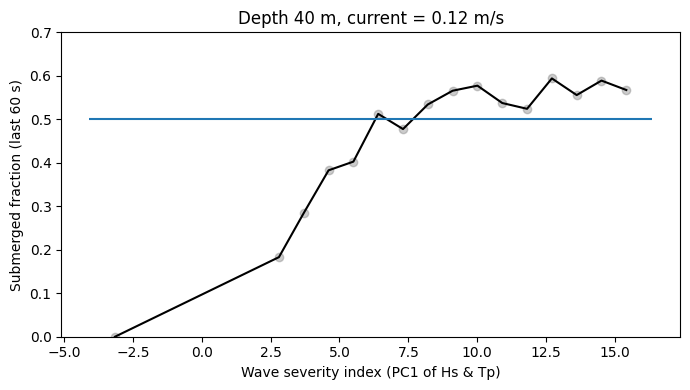

In [10]:
import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR    = Path("./moordyn/results/correct/waves_4_plot")
DEPTH       = 40.0
TARGET_CS   = 0.12       # current speed to plot (m/s)
Z_THRESHOLD = -0.20      # 20 cm below SWL


def parse_fname(fname):
    """
    fname: e.g. '40m_0.12ms_dt1e-04_T846s__Hs_1.00m_Fp_0.20Hz_eta.pkl'
    returns depth, current, Hs, Tp
    """
    parts = fname.split("_")
    depth  = float(parts[0][:-1])     # '40m'   -> 40
    cs     = float(parts[1][:-2])     # '0.12ms'-> 0.12

    if "None" in fname:
        Hs = 0.0
        Tp = 0.0
    else:
        Hs = float(parts[-4][:-1])    # '1.00m' -> 1.00
        Fp = float(parts[-2][:-2])    # '0.20Hz'-> 0.20
        Tp = 1.0 / Fp

    return depth, cs, Hs, Tp


def final_heave_frac(res, z_thres=-0.20):
    """Fraction of the last 60 s with elevation below z_thres."""
    t = res["time_hist"]
    z = res["state_hist"][:, 2]
    waves = res.get("waves", np.zeros_like(t))

    if t[-1] <= 200.0:
        return None

    i0 = np.argmin(np.abs(t - (t[-1] - 60.0)))
    elev = z[i0:] - waves[i0:]
    return 1.0 - np.count_nonzero(elev > z_thres) / elev.size


# --------- collect MoorDyn data at 0.12 m/s and project to PCA axis ---------

wave_idx = []
frac     = []

for path in sorted(BASE_DIR.glob(f"{int(DEPTH)}m_*.pkl")):
    d, cs, Hs, Tp = parse_fname(path.name)
    if abs(d - DEPTH) > 1e-6:
        continue
    if abs(cs - TARGET_CS) > 1e-6:
        continue

    with open(path, "rb") as f:
        res = pickle.load(f)

    f_sub = final_heave_frac(res, Z_THRESHOLD)
    if f_sub is None:
        continue

    x = np.array([Hs, Tp])
    z = (x - mean) / std           # same standardisation as PCA
    wi = float(z @ pc1)            # same PC1 combination

    wave_idx.append(wi)
    frac.append(f_sub)

wave_idx = np.array(wave_idx)
frac     = np.array(frac)

# sort by wave index for plotting
order    = np.argsort(wave_idx)
wave_idx = wave_idx[order]
frac     = frac[order]

# --------- new plot: your own y-axis / scale ---------

fig, ax = plt.subplots(figsize=(7, 4))

from scipy.ndimage import gaussian_filter1d

frac_smooth = gaussian_filter1d(frac, sigma=0.2)


ax.plot(wave_idx, frac, "o", color="grey", alpha=0.4, label="raw")
ax.plot(wave_idx, frac_smooth, "-k", label="smoothed (window=3)")
ax.hlines(0.5, xmin = ax.get_xlim()[0], xmax = ax.get_xlim()[1])
ax.set_xlabel("Wave severity index (PC1 of Hs & Tp)")
ax.set_ylabel("Submerged fraction (last 60 s)")
ax.set_ylim(0.0, 0.7)        # or whatever scale you want
ax.set_title(f"Depth {DEPTH:.0f} m, current = {TARGET_CS:.2f} m/s")

plt.tight_layout()
plt.show()


moordyn/results/correct/waves_4_plot/40m_0.05ms_dt5e-06_T1193s__None.pkl
40m_0.05ms_dt5e-06_T1193s__None.pkl
0.0
moordyn/results/correct/waves_4_plot/40m_0.08ms_dt1e-05_T933s__Hs_3.25m_Fp_0.20Hz_eta.pkl
0.5174708818635607
moordyn/results/correct/waves_4_plot/40m_0.08ms_dt1e-05_T933s__Hs_3.50m_Fp_0.20Hz_eta.pkl
0.47753743760399336
moordyn/results/correct/waves_4_plot/40m_0.08ms_dt1e-05_T933s__Hs_3.75m_Fp_0.20Hz_eta.pkl
0.47088186356073214
moordyn/results/correct/waves_4_plot/40m_0.08ms_dt1e-05_T933s__None.pkl
40m_0.08ms_dt1e-05_T933s__None.pkl
0.0
moordyn/results/correct/waves_4_plot/40m_0.10ms_dt1e-04_T846s__Hs_0.25m_Fp_0.20Hz_eta.pkl
0.03327787021630613
moordyn/results/correct/waves_4_plot/40m_0.10ms_dt1e-04_T846s__Hs_0.25m_Fp_0.50Hz_eta.pkl
0.11148086522462564
moordyn/results/correct/waves_4_plot/40m_0.10ms_dt1e-04_T846s__Hs_0.25m_Fp_1.00Hz_eta.pkl
0.10482529118136441
moordyn/results/correct/waves_4_plot/40m_0.10ms_dt1e-04_T846s__Hs_0.50m_Fp_0.20Hz_eta.pkl
0.2762063227953411
moordyn/

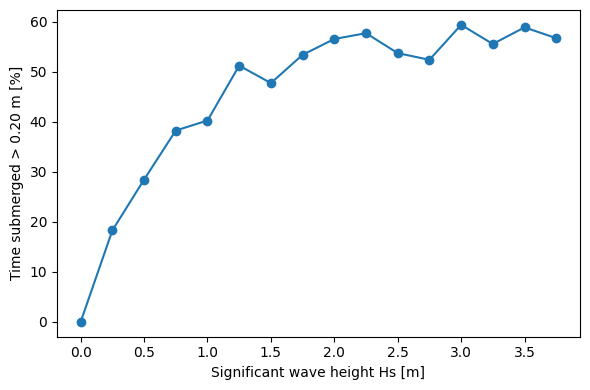

In [11]:
import re
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


# ---------- CONFIG ----------
BASE_DIR = Path("./moordyn/results/correct/waves_4_plot")  # adjust if your files live elsewhere
DEPTH = 40         # depth to plot, e.g. 40 m
Z_THRESHOLD = -0.20   # "below 20 cm under the water line" (assuming z>0 is up)


# ---------- HELPERS ----------

fname_re = re.compile(
    r"(?P<depth>\d+)m_"
    r"(?P<current>[\d.]+)ms_"
    r"dt(?P<dt>[\deE+-]+)_"
    r"T(?P<T>\d+)s__"
    r"Hs_(?P<Hs>[\d.]+)m_"
    r"Fp_(?P<Fp>[\d.]+)Hz_eta\.pkl$"
)


def final_heave_perc(res, z_thres=-0.2):
    time = res["time_hist"]
    state = res["state_hist"]
    try:
        waves = res["waves"]
    except KeyError:
        waves = np.zeros_like(time)

    if np.max(time) > 200:
        last_60 = np.argmin(np.abs(time - (time[-1] - 60)))

        heave = state[:, 2]
        last_heaves = heave[last_60:]
        last_waves = waves[last_60:]
        last_elevations = last_heaves - last_waves

        percentage = 1 - (
            np.count_nonzero(last_elevations > z_thres) / last_heaves.shape[0]
        )
    else:
        percentage = None
    return percentage


def get_depth_cs_t_hs(file_name):
    parts = file_name.split("_")
    depth = float(parts[0][:-1])   # '40m' -> 40
    cs = float(parts[1][:-2])      # '0.10ms' -> 0.10

    if "None" in file_name:
        Hs = 0.0
        T = 0.0
        print(file_name)
    else:
        # ['40m','0.10ms','dt1e-04','T846s','','Hs','1.00m','Fp','0.20Hz','eta.pkl']
        T = 1.0 / float(parts[-2][:-2])   # '0.20Hz' -> 0.20 -> Tp = 1/Fp
        Hs = float(parts[-4][:-1])        # '1.00m'  -> 1.00

    return {
        "depth": depth,
        "current": cs,
        "Tp": T,
        "Hs": Hs,
    }


# ---------- MAIN LOGIC FOR ONE DEPTH ----------

def plot_submergence_vs_wave_for_depth(depth: float, base_dir: Path):
    files = sorted(base_dir.glob(f"{int(depth)}m_*.pkl"))
    if not files:
        raise FileNotFoundError(f"No files found for depth={depth} m in {base_dir}")

    # Collect per-file stats
    records = []
    for path in files:
        print(path)
        dict_row = get_depth_cs_t_hs(path.name)
        with open(path, "rb") as f:
            D = pickle.load(f)
        percentage = final_heave_perc(D)

        if percentage is not None:
            dict_row["frac"] = percentage
            records.append(dict_row)
        print(percentage)

    if not records:
        raise RuntimeError("No valid records (percentage=None everywhere).")

    # Group by current speed
    by_current = {}
    for rec in records:
        by_current.setdefault(rec["current"], []).append(rec)

    # ---- ONLY USE CURRENT ≈ 0.12 m/s ----
    target_current = 0.12
    current_key = None
    for c in by_current.keys():
        if abs(c - target_current) < 1e-6:
            current_key = c
            break

    if current_key is None:
        raise ValueError(
            f"No records found for current ~ {target_current} m/s. "
            f"Available currents: {sorted(by_current.keys())}"
        )

    recs_012 = by_current[current_key]

    # ---- GROUP BY Hs AND AVERAGE frac ----
    hs_groups = {}
    for r in recs_012:
        Hs = r["Hs"]
        hs_groups.setdefault(Hs, []).append(r["frac"])

    Hs_vals = np.array(sorted(hs_groups.keys()))
    frac_mean = np.array([np.mean(hs_groups[Hs]) for Hs in Hs_vals])*100

    fig, ax = plt.subplots(figsize=(6, 4))

    # x-axis = Hs, numeric
    ax.plot(Hs_vals, frac_mean, marker="o", label=f"{current_key:.2f} m/s")

    #ax.set_xticks(Hs_vals)
    #ax.set_xticklabels([f"{Hs:.2g}" for Hs in Hs_vals])

    ax.set_xlabel("Significant wave height Hs [m]")
    ax.set_ylabel("Time submerged > 0.20 m [%]")
    #ax.set_title(f"Depth = {depth:.0f} m (period = 5 s)")

    #ax.grid(True, alpha=0.3)
    #ax.legend(title="Current speed")
    plt.tight_layout()
    plt.savefig("increase_in_coverage_40m_012ms.png", dpi=200)
    plt.show()


plot_submergence_vs_wave_for_depth(DEPTH, BASE_DIR)

